## 5 - Loading Processed Data

In this step, we load processed video dataset from the previously notebook


In [24]:
import cv2
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from PIL import Image
import random
import shutil
from sklearn.model_selection import train_test_split
import networkx as nx
import torch
from tqdm import tqdm
import urllib.request

In [25]:
print("--- LOADING PROCESSED DATA ---")

load_path = "./processed_images/dataframe_images"
full_fei_processed_df = pd.read_csv(load_path)

print(f"{len(full_fei_processed_df)} images loaded!")
pd.set_option('display.max_colwidth', None)
display(full_fei_processed_df.sample(15))

--- LOADING PROCESSED DATA ---
14200 images loaded!


,filename,path,label,subj1,subj2,pose_number,pose_number_2,algorithm,morph_factor_1,morph_factor_2,post_proc_auto,post_proc_manual,digital_ps,resolution,detection_type
14,M_61-11_65-11_C03_B30_W30_PA03_PM00_F00_ssd.png,FEI_Processed/fake/M_61-11_65-11_C03_B30_W30_PA03_PM00_F00_ssd.png,1,61,65.0,11,11.0,C03,B30,W30,PA03,PM00,F00,224x224,ssd
6515,M_29-11_21-11_C15_B30_W30_PA15_PM00_F00_ssd.png,FEI_Processed/fake/M_29-11_21-11_C15_B30_W30_PA15_PM00_F00_ssd.png,1,29,21.0,11,11.0,C15,B30,W30,PA15,PM00,F00,224x224,ssd
6099,M_56-11_74-11_C15_B30_W30_PA15_PM00_F00_ssd.png,FEI_Processed/fake/M_56-11_74-11_C15_B30_W30_PA15_PM00_F00_ssd.png,1,56,74.0,11,11.0,C15,B30,W30,PA15,PM00,F00,224x224,ssd
2906,M_150-11_125-11_C16_B50_W50_PA16_PM00_F00_ssd.png,FEI_Processed/fake/M_150-11_125-11_C16_B50_W50_PA16_PM00_F00_ssd.png,1,150,125.0,11,11.0,C16,B50,W50,PA16,PM00,F00,224x224,ssd
12250,M_64-11_83-11_C15_B30_W30_PA15_PM00_F00_ssd.png,FEI_Processed/fake/M_64-11_83-11_C15_B30_W30_PA15_PM00_F00_ssd.png,1,64,83.0,11,11.0,C15,B30,W30,PA15,PM00,F00,224x224,ssd
117,M_167-11_110-11_C02_B30_W30_PA02_PM00_F00_ssd.png,FEI_Processed/fake/M_167-11_110-11_C02_B30_W30_PA02_PM00_F00_ssd.png,1,167,110.0,11,11.0,C02,B30,W30,PA02,PM00,F00,224x224,ssd
5748,M_145-11_25-11_C01_B50_W50_PA01_PM00_F00_ssd.png,FEI_Processed/fake/M_145-11_25-11_C01_B50_W50_PA01_PM00_F00_ssd.png,1,145,25.0,11,11.0,C01,B50,W50,PA01,PM00,F00,224x224,ssd
8926,M_95-11_94-11_C05_B50_W50_PA05_PM00_F00_ssd.png,FEI_Processed/fake/M_95-11_94-11_C05_B50_W50_PA05_PM00_F00_ssd.png,1,95,94.0,11,11.0,C05,B50,W50,PA05,PM00,F00,224x224,ssd
6358,M_137-11_16-11_C16_B50_W50_PA16_PM00_F00_ssd.png,FEI_Processed/fake/M_137-11_16-11_C16_B50_W50_PA16_PM00_F00_ssd.png,1,137,16.0,11,11.0,C16,B50,W50,PA16,PM00,F00,224x224,ssd
11865,M_106-11_125-11_C16_B50_W50_PA16_PM00_F00_ssd.png,FEI_Processed/fake/M_106-11_125-11_C16_B50_W50_PA16_PM00_F00_ssd.png,1,106,125.0,11,11.0,C16,B50,W50,PA16,PM00,F00,224x224,ssd


## 6 - Data Split (70/15/15) & Identity Isolation

To ensure the scientific validity of the training process, the **FEI Morph** dataset is split using a strict **Identity-Based** approach. Standard random splitting is avoided to prevent **Data Leakage**, which occurs when the model recognizes a specific person's features rather than the actual morphing artifacts.

### The Identity Isolation Strategy
A "Fake" (Morph) image is a combination of two identities: **Subject 1** and **Subject 2**. To guarantee that the model is tested on entirely unseen faces, we implement a **Link-Breaking** strategy:

* **Subject Partitioning**: All 200 unique subjects are randomly assigned to three isolated pools: **Train (70%)**, **Validation (15%)**, and **Test (15%)**.
* **Strict Assignment**: 
    * **Originals**: Assigned based on the subject's pool.
    * **Morphs**: Kept only if **both** involved subjects belong to the same pool.
* **Link Breaking**: Morphs that bridge two different splits (e.g., Subject A in Train and Subject B in Test) are **discarded**.

This rigorous method ensures **zero identity overlap** between splits. While this results in discarding a significant portion of the morphing images (those connecting different pools), it is a necessary requirement to build a model that generalizes to new faces and provides reliable, honest performance metrics.


In [26]:
def split_fei_by_breaking_links(df, train_size=0.7, val_size=0.15):
    all_subjects = sorted(list(set(df['subj1'].unique())))
    random.seed(42)
    random.shuffle(all_subjects)

    n = len(all_subjects)
    tr_idx = int(n * train_size)
    vl_idx = int(n * (train_size + val_size))

    train_pool = set(all_subjects[:tr_idx])
    val_pool = set(all_subjects[tr_idx:vl_idx])
    test_pool = set(all_subjects[vl_idx:])

    def assign(row):
        s1, s2 = row['subj1'], row['subj2']
        
        if pd.isna(s2) or s2 == "":
            if s1 in train_pool: return 'train'
            if s1 in val_pool: return 'val'
            return 'test'
        
        # Morph images (Fake) - BOTH subjects must be in the same pool
        # This is the "Link Breaking" part
        if s1 in train_pool and s2 in train_pool: return 'train'
        if s1 in val_pool and s2 in val_pool: return 'val'
        if s1 in test_pool and s2 in test_pool: return 'test'
        
        # If Subj1 is in Train but Subj2 is in Test, we DISCARD to prevent leakage
        return 'discard'

    df['split'] = df.apply(assign, axis=1)


    df_final = df[df['split'] != 'discard'].copy()
    
    print(f"--- SPLIT REPORT ---")
    print(f"Total images before: {len(df)}")
    print(f"Total images kept:   {len(df_final)}")
    print(f"Images discarded to prevent leakage: {len(df) - len(df_final)}")
    return df_final

full_fei_processed_df = split_fei_by_breaking_links(full_fei_processed_df)

print("\n--- STATISTICS ---")
print(full_fei_processed_df['split'].value_counts())
full_fei_processed_df.head()

--- SPLIT REPORT ---
Total images before: 14200
Total images kept:   8054
Images discarded to prevent leakage: 6146

--- STATISTICS ---
split
train    7462
test      352
val       240
Name: count, dtype: int64


,filename,path,label,subj1,subj2,pose_number,pose_number_2,algorithm,morph_factor_1,morph_factor_2,post_proc_auto,post_proc_manual,digital_ps,resolution,detection_type,split
0,M_82-11_49-11_C03_B30_W30_PA03_PM00_F00_ssd.png,FEI_Processed/fake/M_82-11_49-11_C03_B30_W30_PA03_PM00_F00_ssd.png,1,82,49.0,11,11.0,C03,B30,W30,PA03,PM00,F00,224x224,ssd,train
1,M_109-11_9-11_C03_B50_W50_PA03_PM00_F00_ssd.png,FEI_Processed/fake/M_109-11_9-11_C03_B50_W50_PA03_PM00_F00_ssd.png,1,109,9.0,11,11.0,C03,B50,W50,PA03,PM00,F00,224x224,ssd,test
2,M_121-11_128-11_C02_B50_W50_PA02_PM00_F00_ssd.png,FEI_Processed/fake/M_121-11_128-11_C02_B50_W50_PA02_PM00_F00_ssd.png,1,121,128.0,11,11.0,C02,B50,W50,PA02,PM00,F00,224x224,ssd,train
3,M_121-11_170-11_C15_B50_W50_PA15_PM00_F00_ssd.png,FEI_Processed/fake/M_121-11_170-11_C15_B50_W50_PA15_PM00_F00_ssd.png,1,121,170.0,11,11.0,C15,B50,W50,PA15,PM00,F00,224x224,ssd,train
4,M_194-11_112-11_C15_B30_W30_PA15_PM00_F00_ssd.png,FEI_Processed/fake/M_194-11_112-11_C15_B30_W30_PA15_PM00_F00_ssd.png,1,194,112.0,11,11.0,C15,B30,W30,PA15,PM00,F00,224x224,ssd,train


In [27]:
train_subjs = set(full_fei_processed_df[full_fei_processed_df['split'] == 'train']['subj1'].unique())
val_subjs   = set(full_fei_processed_df[full_fei_processed_df['split'] == 'val']['subj1'].unique())
test_subjs  = set(full_fei_processed_df[full_fei_processed_df['split'] == 'test']['subj1'].unique())

#Leakage check
train_test_int = train_subjs.intersection(test_subjs)
train_val_int  = train_subjs.intersection(val_subjs)
val_test_int   = val_subjs.intersection(test_subjs)

print("--- IDENTITY LEAKAGE CHECK ---")

if len(train_test_int) == 0 and len(train_val_int) == 0 and len(val_test_int) == 0:
    print("TEST PASSED: No subjects from the Training set are present in the Validation or Test sets.")
    print(f"Total Unique Subjects: {len(train_subjs | val_subjs | test_subjs)}")
    print(f"  -> Train Subjects: {len(train_subjs)}")
    print(f"  -> Val Subjects:   {len(val_subjs)}")
    print(f"  -> Test Subjects:  {len(test_subjs)}")
else:
    print(f"WARNING: Identity Leakage detected!")
    if len(train_test_int) > 0:
        print(f"  -> {len(train_test_int)} subjects shared between Train and Test.")
    if len(train_val_int) > 0:
        print(f"  -> {len(train_val_int)} subjects shared between Train and Val.")
    if len(val_test_int) > 0:
        print(f"  -> {len(val_test_int)} subjects shared between Val and Test.")

--- IDENTITY LEAKAGE CHECK ---
TEST PASSED: No subjects from the Training set are present in the Validation or Test sets.
Total Unique Subjects: 200
  -> Train Subjects: 140
  -> Val Subjects:   30
  -> Test Subjects:  30


In [28]:
# CONFIGURATION
source_root = "FEI_Processed" 
output_root = "FEI_Split" 

splits = ['train', 'val', 'test']
categories = ['original', 'fake']

for s in splits:
    for cat in categories:
        os.makedirs(os.path.join(output_root, s, cat), exist_ok=True)

print(f"--- STARTING PHYSICAL FILE COPY TO {output_root} ---")

copy_count = 0
error_count = 0

for idx, row in tqdm(full_fei_processed_df.iterrows(), total=len(full_fei_processed_df)):
    current_path = row['path']
    split_folder = row['split'] # 'train', 'val', o 'test'
    
    cat_folder = 'original' if str(row['label']) in ['0', '0.0', 'original'] else 'fake'
    
    new_filename = row['filename']
    destination_path = os.path.join(output_root, split_folder, cat_folder, new_filename)
    
    try:
        if os.path.exists(current_path):
            shutil.copy2(current_path, destination_path)
            full_fei_processed_df.at[idx, 'path'] = os.path.abspath(destination_path)
            copy_count += 1
        else:
            error_count += 1
    except Exception as e:
        print(f"Error copying {current_path}: {e}")
        error_count += 1

print(f"\n--- COPY COMPLETED ---")
print(f"Files successfully copied: {copy_count}")
print(f"Files missing or errors:   {error_count}")

for s in splits:
    for cat in categories:
        p = os.path.join(output_root, s, cat)
        num_files = len([f for f in os.listdir(p) if not f.startswith('.')])
        print(f"Folder {s}/{cat}: {num_files} images")

--- STARTING PHYSICAL FILE COPY TO FEI_Split ---


100%|██████████| 8054/8054 [00:04<00:00, 1722.55it/s]


--- COPY COMPLETED ---
Files successfully copied: 8054
Files missing or errors:   0
Folder train/original: 140 images
Folder train/fake: 7322 images
Folder val/original: 30 images
Folder val/fake: 210 images
Folder test/original: 30 images
Folder test/fake: 322 images


## 7 - Sanity Check & Detection Analysis

In [29]:
print("--- FEI MORPH SANITY CHECK & DETECTION ANALYSIS ---")

def count_methods(base_dir):
    """Counts files on disk, distinguishing between _ssd and _cc suffixes"""
    if not os.path.exists(base_dir):
        return 0, 0, 0
    
    total, ssd, cc = 0, 0, 0
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                total += 1
                if '_ssd' in file:
                    ssd += 1
                elif '_cc' in file:
                    cc += 1
    return total, ssd, cc

expected_total = len(full_fei_processed_df)
processed_path = "FEI_Processed"

actual_total, total_ssd, total_cc = count_methods(processed_path)

print(f"\nExpected images (from DataFrame): {expected_total}")
print(f"Found images (on Disk):          {actual_total}")

# Integrity Check
if expected_total == actual_total and expected_total > 0:
    print("STATUS: PERFECT! The number of files matches the DataFrame.")
elif actual_total == 0:
    print("STATUS: ERROR! No files found in the directory.")
else:
    print(f"STATUS: MISMATCH! {expected_total - actual_total} images are missing on disk.")

# Detection Quality Analysis
if actual_total > 0:
    ssd_pct = (total_ssd / actual_total) * 100
    cc_pct = (total_cc / actual_total) * 100
    
    print("\n--- DETECTION QUALITY STATISTICS ---")
    print(f"SSD Face Detector:    {total_ssd} ({ssd_pct:.1f}%)")
    print(f"Center Crop Fallback: {total_cc} ({cc_pct:.1f}%)")
    
    if ssd_pct > 90:
        print("\nExcellent! The AI found almost all faces.")
    elif ssd_pct < 50:
        print("\nWarning: More than half of the images used Center Crop. Check the quality.")

print("\n--- CLASS DISTRIBUTION ON DISK ---")
for label_folder in ["original", "fake"]:
    label_path = os.path.join(processed_path, label_folder)
    if os.path.exists(label_path):
        count = len([f for f in os.listdir(label_path) if os.path.isfile(os.path.join(label_path, f)) and not f.startswith('.')])
        print(f"  -> Folder '{label_folder}': {count} images")

--- FEI MORPH SANITY CHECK & DETECTION ANALYSIS ---

Expected images (from DataFrame): 8054
Found images (on Disk):          14200
STATUS: MISMATCH! -6146 images are missing on disk.

--- DETECTION QUALITY STATISTICS ---
SSD Face Detector:    14200 (100.0%)
Center Crop Fallback: 0 (0.0%)

Excellent! The AI found almost all faces.

--- CLASS DISTRIBUTION ON DISK ---
  -> Folder 'original': 200 images
  -> Folder 'fake': 14000 images


## 8 - Visual Sanity Check

--- VISUAL SANITY CHECK (BALANCED) ---


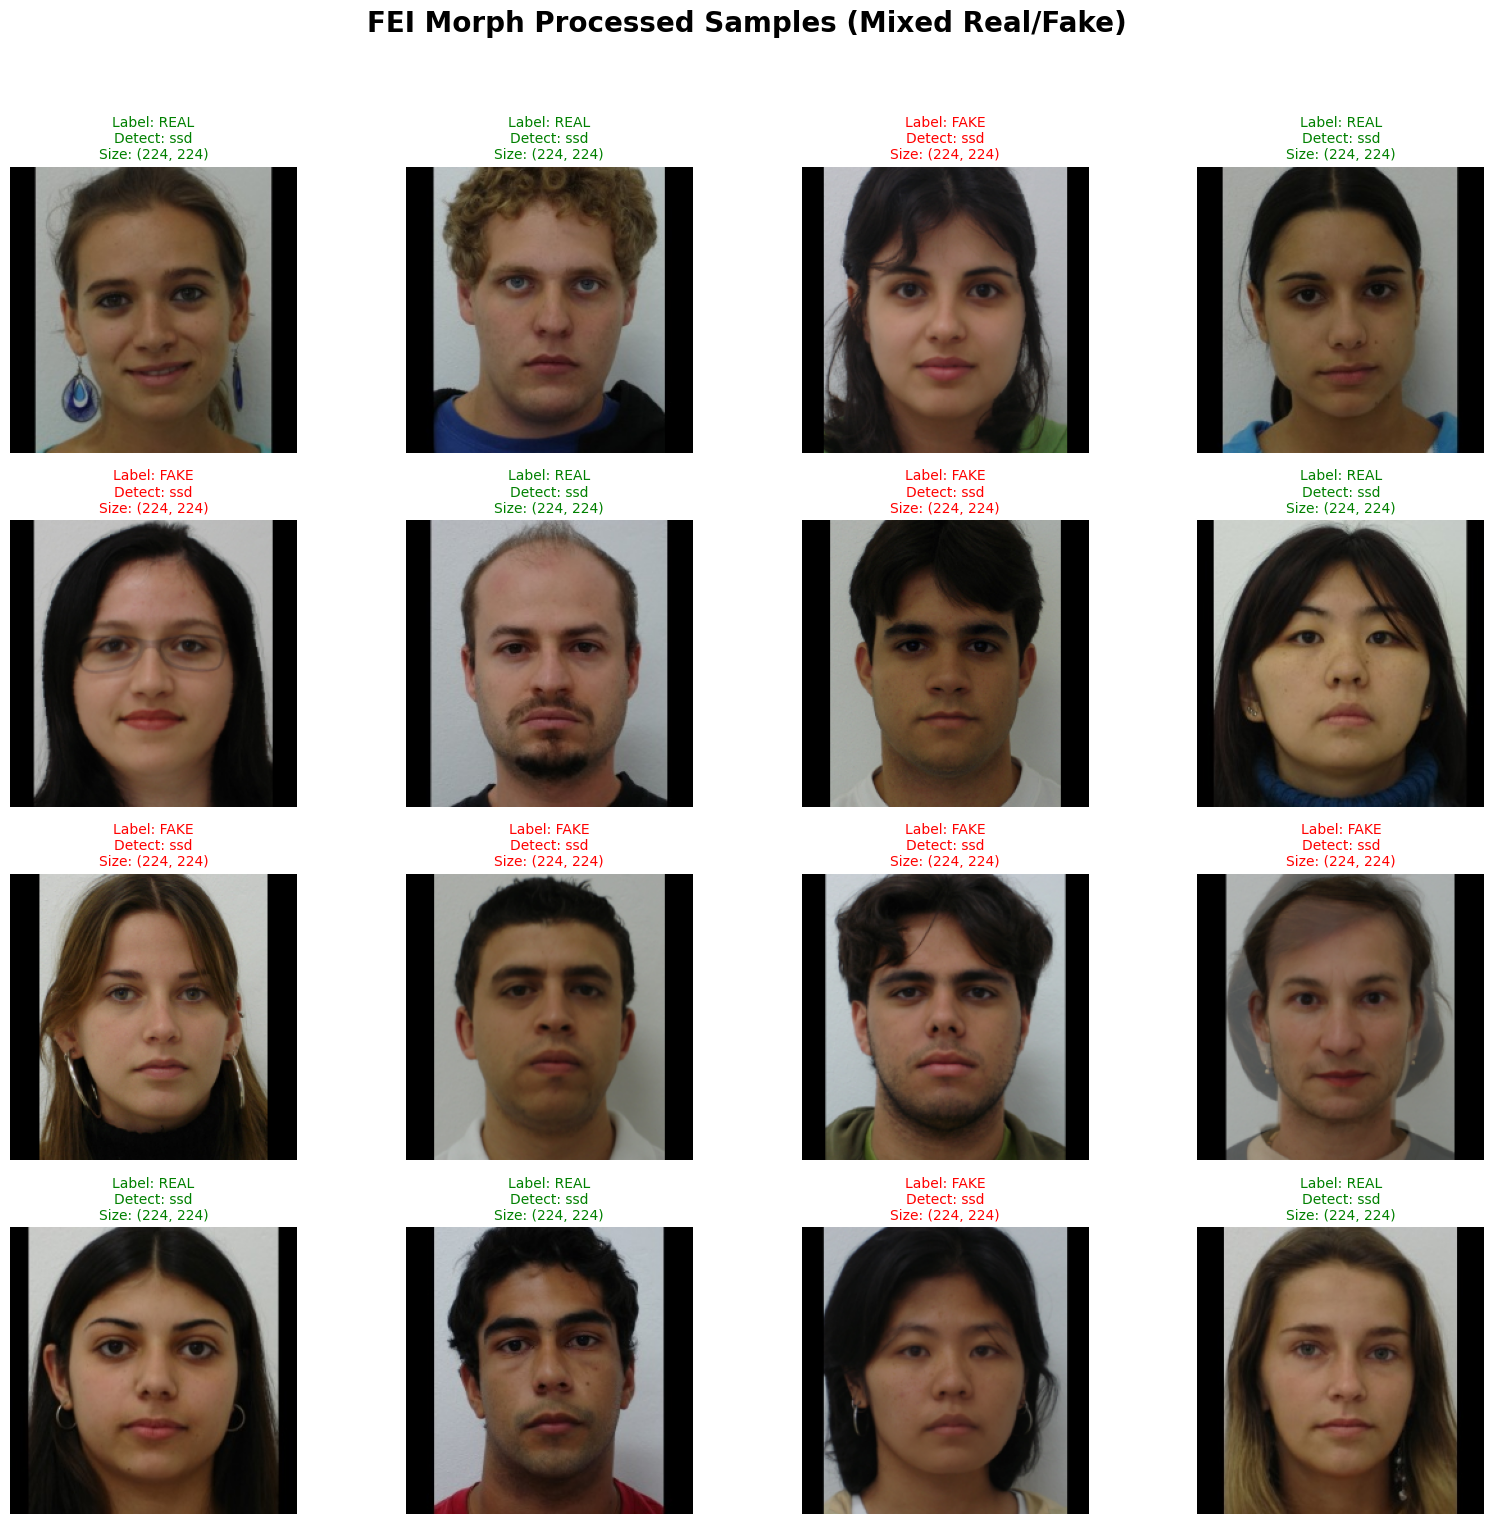

In [30]:
print("--- VISUAL SANITY CHECK (BALANCED) ---")

def visual_check_balanced(df, n_samples=16):
    if len(df) == 0:
        print("ERROR: DataFrame is empty.")
        return

    df_fake = df[df['label'].astype(str).isin(['1', '1.0', 'fake'])]
    df_real = df[df['label'].astype(str).isin(['0', '0.0', 'original', 'real'])]

    half = n_samples // 2
    
    s_fake = df_fake.sample(min(half, len(df_fake)), random_state=42)
    s_real = df_real.sample(min(half, len(df_real)), random_state=42)
    
    samples = pd.concat([s_fake, s_real]).sample(frac=1).reset_index(drop=True)

    rows = 4
    cols = 4
    fig, axes = plt.subplots(rows, cols, figsize=(16, 16))
    fig.suptitle("FEI Morph Processed Samples (Mixed Real/Fake)", fontsize=20, fontweight='bold')
    axes = axes.flatten()

    for i, (idx, row) in enumerate(samples.iterrows()):
        if i >= len(axes): break
        ax = axes[i]
        img_path = row['path']

        current_label = str(row['label'])
        is_fake = current_label in ['1', '1.0', 'fake']
        label_text = "FAKE" if is_fake else "REAL"
        
        method = row['detection_type']
        
        try:
            img = Image.open(img_path)
            ax.imshow(img)
            
            color = 'red' if is_fake else 'green'
            ax.set_title(f"Label: {label_text}\nDetect: {method}\nSize: {img.size}", color=color, fontsize=10)
        except Exception as e:
            ax.text(0.5, 0.5, "Load Error", ha='center', va='center')
        
        ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

visual_check_balanced(full_fei_processed_df)